<a href="https://colab.research.google.com/github/alimohmedelsaid26-cell/1000MLEngineer/blob/main/Football_transfer_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns
import numpy as np
np.random.seed(300) # To give constant result
#Reading File
df=pd.read_csv("Summer22_FootballTransfers.csv.zip")

Splitting data into Training and Testing

In [27]:

from sklearn.model_selection import train_test_split
X=df_3.drop("cost",axis=1)
y=df_3["cost"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.30,random_state=0,shuffle=True)
print("x_train shape is:",X_train.shape)
print("x_test shape is:",X_test.shape)
print("y_train shape is:",y_train.shape)
print("y_test shape is:",y_test.shape)

x_train shape is: (18895, 9)
x_test shape is: (8099, 9)
y_train shape is: (18895,)
y_test shape is: (8099,)


Regression

Gradient Boosting regression Using scikit-learn

In [28]:
from sklearn.ensemble import GradientBoostingRegressor
GBR = GradientBoostingRegressor(n_estimators=300,learning_rate=0.4,random_state=0)
GBR.fit(X_train, y_train)  # Train the model
y_pred = GBR.predict(X_test) # Test the model

In [30]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn import metrics

# Initialize with Early Stopping parameters
GBR = GradientBoostingRegressor(
    n_estimators=2000,      # A high limit
    learning_rate=0.1,      # Lower rate for better precision
    validation_fraction=0.1, # Reserve 10% of training data for internal testing
    n_iter_no_change=10,    # Stop if no improvement after 10 trees
    tol=1e-4,               # The minimum change to qualify as an improvement
    random_state=0
)

# Train the model
GBR.fit(X_train, y_train)

# Check how many trees were actually built
actual_trees = len(GBR.estimators_)
print(f"Model stopped early at: {actual_trees} trees")

# Evaluate
y_pred = GBR.predict(X_test)
r2_score = metrics.r2_score(y_test, y_pred)
print(f"R2 Score: {r2_score:.4f}")

Model stopped early at: 55 trees
R2 Score: 0.3074


In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Calculate additional metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R2 Score: {r2_score:.4f}")

Mean Absolute Error (MAE): 0.01
Root Mean Squared Error (RMSE): 0.04
R2 Score: 0.3074


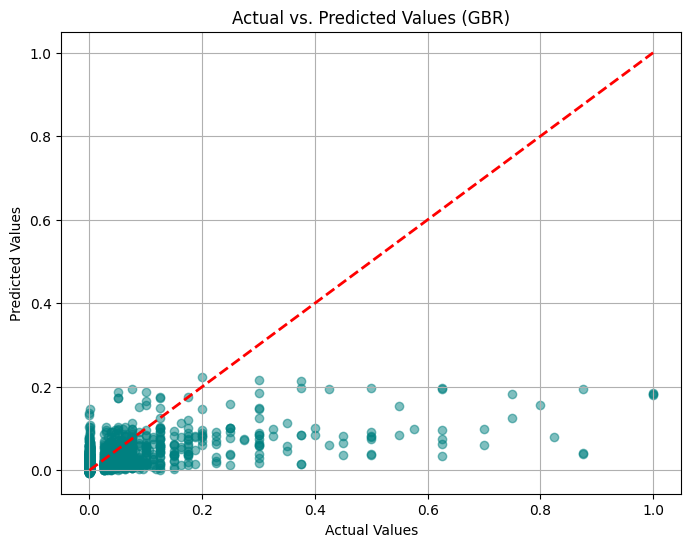

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values (GBR)')
plt.grid(True)
plt.show()

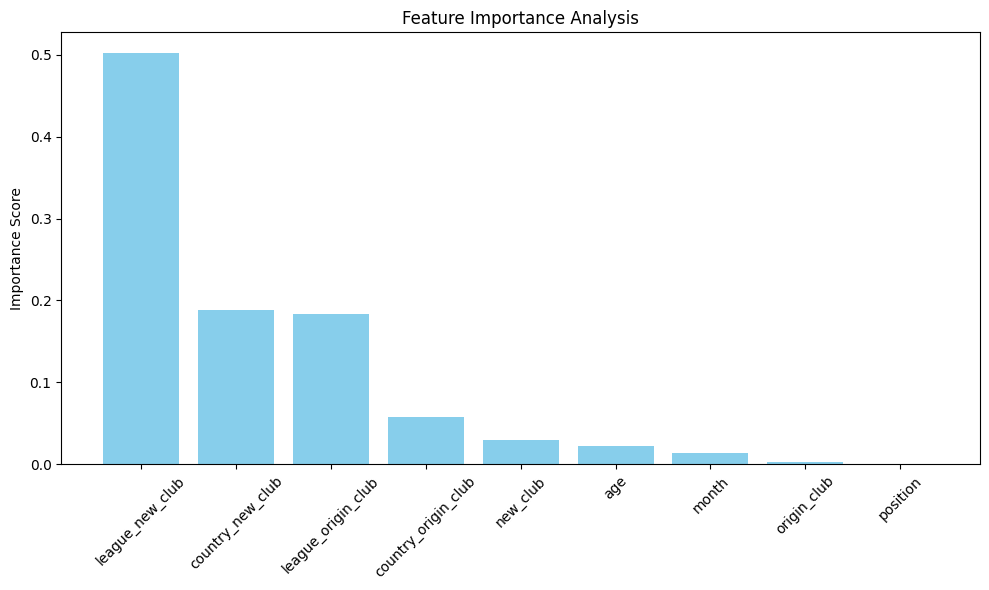

In [33]:
# Extract and sort feature importances
importances = GBR.feature_importances_
indices = np.argsort(importances)[::-1]

# Plotting
plt.figure(figsize=(10, 6))
plt.title("Feature Importance Analysis")
plt.bar(range(X_train.shape[1]), importances[indices], align="center", color='skyblue')
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=45)
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

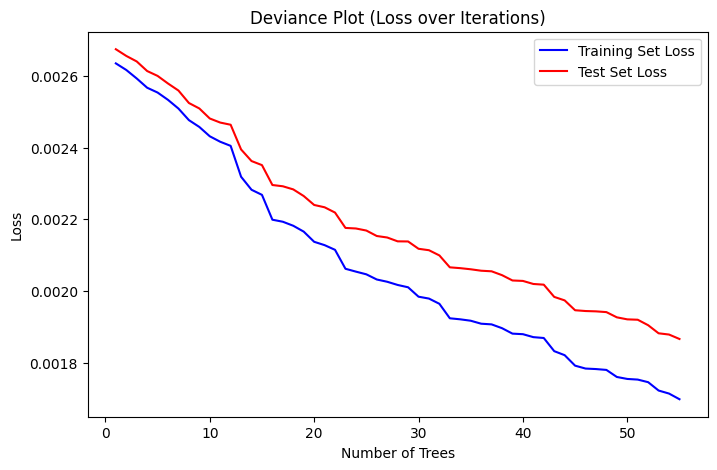

In [35]:
# Compute test set deviance
from sklearn.metrics import mean_squared_error # Import mean_squared_error

test_score = np.zeros((GBR.n_estimators,), dtype=np.float64)
for i, y_pred_step in enumerate(GBR.staged_predict(X_test)):
    test_score[i] = mean_squared_error(y_test, y_pred_step) # Use mean_squared_error

plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(GBR.estimators_)) + 1, GBR.train_score_, 'b-', label='Training Set Loss')
plt.plot(np.arange(len(GBR.estimators_)) + 1, test_score[:len(GBR.estimators_)], 'r-', label='Test Set Loss')
plt.title('Deviance Plot (Loss over Iterations)')
plt.xlabel('Number of Trees')
plt.ylabel('Loss')
plt.legend()
plt.show()